In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

from RunSimulator import RunSimulator
from PathPlotter import PathPlotter
master = RunSimulator()

"""
hi indira & tristan & whoever else it concerns
youll have to run this jupyter notebook from beginning prob
tips for jupyter notebook:
1) keep track of what you ran. try NOT to run cells out of order.
2) this may seem easier than normal coding but its actually like not. be careful.
3) fyi ipynbs are 'modified' if code OR cell output changes
"""

"\nhi indira & tristan & whoever else it concerns\nyoull have to run this jupyter notebook from beginning prob\ntips for jupyter notebook:\n1) keep track of what you ran. try NOT to run cells out of order.\n2) this may seem easier than normal coding but its actually like not. be careful.\n3) fyi ipynbs are 'modified' if code OR cell output changes\n"

In [19]:
#baseline constants
baseline_trial_num = 10
error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim=20000
deltahead=2.4

#running trials!
random.seed(42) # NOTE: only set this when you want to RESET the module
master.baseline(7, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead)
rand_state = random.getstate()

the mouse moved this far: 324.8378051033331
[[-72.11040188 316.73283626]]
[-72.72942839 291.82497952]
the mouse moved this far: 645.4915509755027
[[-93.12732954 638.73832113]]
[-86.58856339 681.27835915]
the mouse moved this far: 830.8038755403552
[[334.79828485 760.35859177]]
[344.29144416 766.71265978]
the mouse moved this far: 590.563512381621
[[249.7969485  535.13245713]]
[256.57491963 572.09033771]
the mouse moved this far: 305.990081648238
[[223.24507229 209.26434901]]
[227.99111735 197.60919788]
the mouse moved this far: 695.1659687110055
[[618.37083717 317.60546561]]
[637.40521472 307.07121493]
the mouse moved this far: 612.8661508425307
[[-214.45005275 -574.12201989]]
[-229.88260361 -580.03546458]


In [21]:
random.setstate(rand_state)
master.baseline(1, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead)
baseline_final_drifts = master.all_final_drift
baseline_mean_errors = master.all_mean_error
baseline_rmses = master.all_rmse
baseline_errors_over_time = master.all_error_over_time

the mouse moved this far: 1074.768999156258
[[ 327.52475643 1023.64834561]]
[ -843.97232722 -1024.40853096]


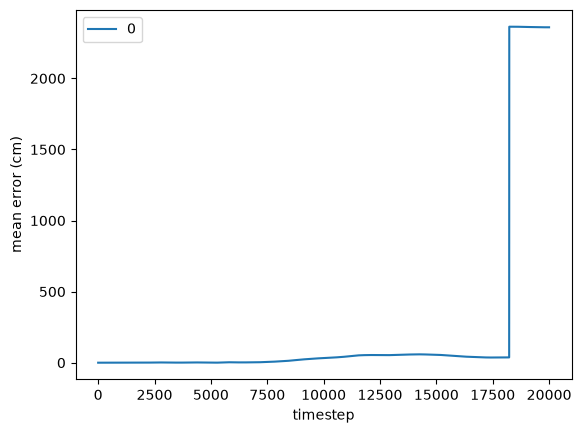

In [ ]:
%matplotlib inline
#plot error over time
x = np.arange(sim) # this only works now in this specific case bc error_freq=1
y = np.mean(baseline_errors_over_time, axis=0)
y_list = baseline_errors_over_time

#y=master.error_over_time_i
for i in range(1):
    plt.plot(x,y_list[i],label=i)
plt.xlabel('timestep')
plt.ylabel('mean error (cm)')
plt.legend()
plt.show()

In [25]:
rand_state

(3,
 (3570491089,
  93972687,
  1790669100,
  942973607,
  717892226,
  3461295422,
  3595252805,
  3015388314,
  990892930,
  2892785734,
  2378607755,
  1261796487,
  2146622866,
  1257376466,
  2982072246,
  1633002247,
  2096759875,
  507945513,
  3799746665,
  1656619249,
  1170157397,
  131416144,
  1754032050,
  109921358,
  1775035039,
  3369990048,
  47732077,
  1713605609,
  239721989,
  1260045961,
  3625837540,
  321554893,
  850433178,
  37805798,
  1399527944,
  1792659611,
  3333217432,
  3968954065,
  2278154407,
  3065208757,
  2151866292,
  3437817942,
  2837324348,
  3973713588,
  232276472,
  1750080663,
  3996840783,
  141644430,
  1658913783,
  3483369994,
  2051239963,
  1852251523,
  3225506285,
  4120012029,
  3765012799,
  469268868,
  3700689050,
  3997193528,
  597212442,
  928267768,
  510516675,
  964093631,
  2685715705,
  4092594525,
  4170474673,
  326026729,
  2199705785,
  1850533773,
  1441393268,
  1596357684,
  655836341,
  639400092,
  2561619059,

In [7]:
#plot true path vs sim path over time
%matplotlib qt

pathplotter = PathPlotter()
path_array = np.zeros((2,sim,2))
path_array[0] = master.trimmed_og_pos
path_array[1] = master.trimmed_sim_pos
# pathplotter.paths(path_array, colors=["black", "blue"],labels=["tru", "sim"])

walk_x = path_array[0][:, 0]
model_x = path_array[1][:, 0]

plt.plot(walk_x, 'D-', label='walk')
plt.plot(model_x, 'D-', label='model')
plt.xlabel('timestep')
plt.ylabel('x position (cm)')

plt.show()


In [17]:
#simulation time trial constants
simlen_trial_num = 3
simlen_iters = 10

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_list=(np.arange(simlen_iters)+1)*10000
deltahead=2.4

#running trials!
sim_trial_final_drifts = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_mean_errors = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_rmses = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_errors_over_time = [] #NOT a numpy array. its a 3d one, iter x simlen trial_num x floor(simlen/errorfreq)

for i in range(simlen_iters):
    master.baseline(simlen_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_list[i], deltahead=deltahead)
    sim_trial_final_drifts[i] = master.all_final_drift
    sim_trial_mean_errors[i] = master.all_mean_error
    sim_trial_rmses[i] = master.all_rmse
    sim_trial_errors_over_time.append(master.all_error_over_time)

the mouse moved this far: 400.85624507863236
[[ 73.61503462 394.03877461]]
[ 68.20543432 412.55418129]
the mouse moved this far: 432.95029128523805
[[421.74583437 -97.8591126 ]]
[ 442.67457791 -105.79839836]
the mouse moved this far: 343.2740563099312
[[241.77797498 243.68112063]]
[259.12456243 261.49575733]
the mouse moved this far: 769.6306167126454
[[ 706.4463433  -305.39294396]]
[ 713.60086274 -333.36184298]
the mouse moved this far: 642.6573537232538
[[584.2974728  267.59098933]]
[591.858227   252.67686545]
the mouse moved this far: 621.6513305864074
[[ 362.79877393 -504.80434473]]
[ 354.8633537  -504.52655205]
the mouse moved this far: 626.5619015143376
[[-596.8355601   190.70167967]]
[-593.9620353   196.19999017]
the mouse moved this far: 732.7751729286965
[[161.38906221 714.78180213]]
[181.58210719 745.80827145]
the mouse moved this far: 339.33102437224557
[[117.27033304 318.42300967]]
[109.8458768  317.94916871]
the mouse moved this far: 561.4025225556919
[[556.85709864  71.29

KeyboardInterrupt: 

In [ ]:
print(sim_trial_final_drifts.shape)
print(sim_trial_mean_errors.shape)
print(sim_trial_rmses.shape)
print(f"{len(sim_trial_errors_over_time)}, {len(sim_trial_errors_over_time[0])}, {len(sim_trial_errors_over_time[0][0])}")

(10, 3)
(10, 3)
(10, 3)
10, 3, 10000


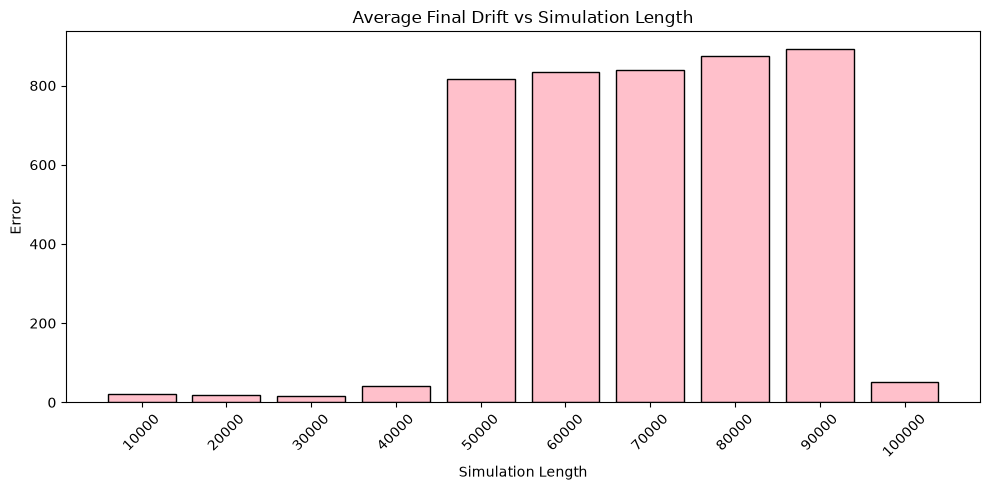

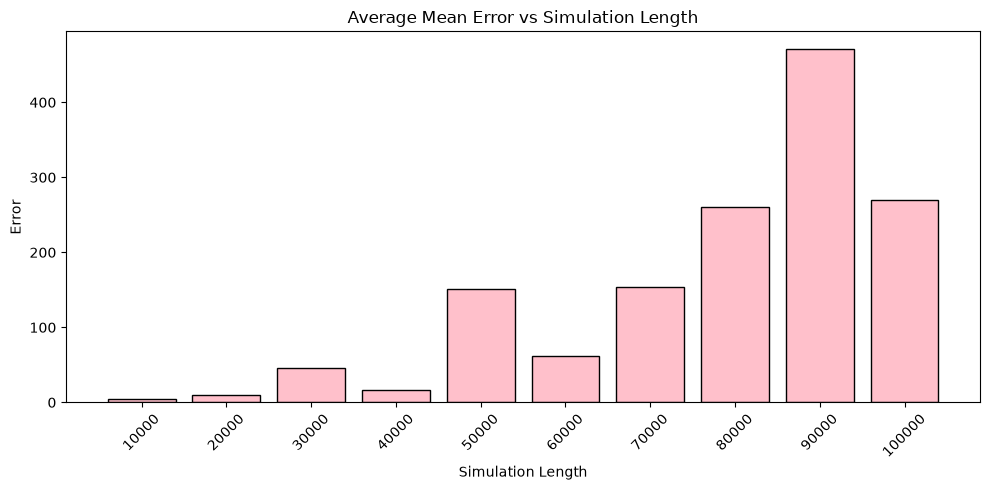

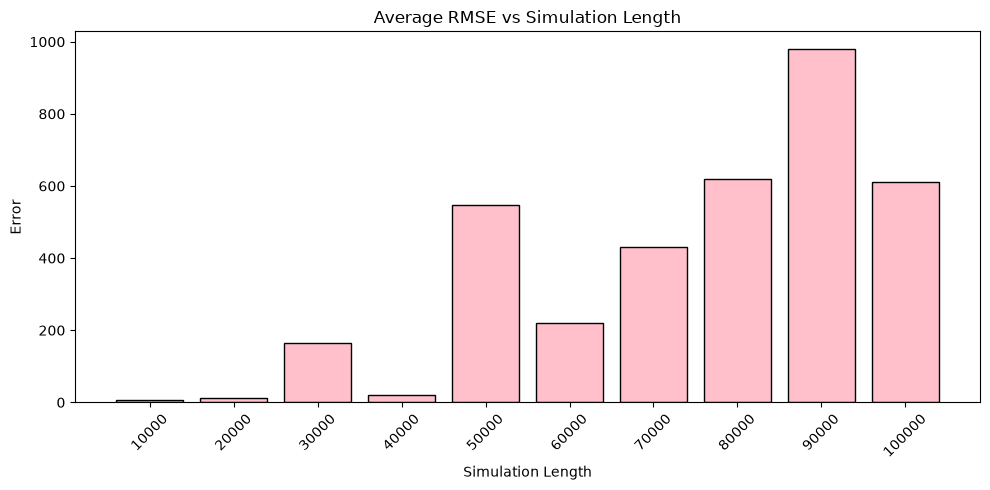

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [f"{(i + 1) * 10000}" for i in range(10)]
x_pos = np.arange(len(x_labels))

avg_final_drifts = np.mean(sim_trial_final_drifts, axis=1)
avg_mean_errors = np.mean(sim_trial_mean_errors, axis=1)
avg_rmses = np.mean(sim_trial_rmses, axis=1)

sim_graphs = [
    ("Final Drift", avg_final_drifts),
    ("Mean Error", avg_mean_errors),
    ("RMSE", avg_rmses),
]

for title, data in sim_graphs:
    plt.figure(figsize=(10, 5))
    plt.bar(x_pos, data, color="pink", edgecolor="black")
    plt.xticks(x_pos, x_labels, rotation=45)
    plt.xlabel("Simulation Length")
    plt.ylabel("Error")
    plt.title(f"Average {title} vs Simulation Length")
    plt.tight_layout()
    plt.show()

In [ ]:
# module number trial . keep range the same from 25 cm to 22.6m
module_num_trial_num = 3
module_num_iters = range(5,14)
module_num_spacings = [np.power(2266./25., (1/i)) for i in module_num_iters]
module_num_len = len(module_num_iters)

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim = 20000
deltahead=2.4

#running trials!
module_num_final_drifts = np.zeros((module_num_len,module_num_trial_num))
module_num_mean_errors = np.zeros((module_num_len,module_num_trial_num))
module_num_rmses = np.zeros((module_num_len,module_num_trial_num))
module_num_errors_over_time = [] #NOT a numpy array. its a 3d one, len x trial_num x floor(simlen/errorfreq)

for i in range(module_num_len):
    master.baseline(module_num_len, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=module_num_iters[i], spacing_min=25,spacing = module_num_spacings[i])
    module_num_final_drifts[i] = master.all_final_drift
    module_num_mean_errors[i] = master.all_mean_error
    module_num_rmses[i] = master.all_rmse
    module_num_errors_over_time.append(master.all_error_over_time)

TypeError: RunSimulator.baseline() got an unexpected keyword argument 'spacing_min'

In [ ]:
"""tristan ... if you want can you make BAR charts of 
module_num_final_drifts, module_num_mean_errors, module_num_rmses
 (theres like 9 bars) 
x goes from 5 to 13
y is the error 
"""

In [ ]:
# module spacing trial..... do tmrw sophie
